In [ ]:
RNN
Monthly Milk Production Forecasting 
Using RNN, LSTM, and GRU Deep Learning Models
Step 1: Identify the Business Problem
From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.
Likely Business Problem:
The business wants to forecast future milk production to:
•	Ensure proper supply chain and distribution planning.
•	Manage inventory and storage efficiently.
•	Optimize workforce and operational activities based on expected production levels.
•	Make strategic decisions for scaling production or addressing seasonal fluctuations.
________________________________________
Step 2: Define the Objective
Objective Statement:
The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.

Steps to include;
✅ Assignment Tasks
1.	Exploratory Data Analysis (EDA)
o	Visualize trends, seasonality, and anomalies in the milk production data.
o	Check for any missing values or outliers.
o	Normalize or scale the data for neural network models.
2.	Data Preparation for Deep Learning
o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
o	Split data into training, validation, and test sets.
o	Reshape data for model input dimensions.
3.	Model Building
o	Build three separate models:
	Basic RNN
	LSTM
	GRU
o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).
o	Use appropriate loss functions and optimizers.
4.	Model Evaluation
o	Plot predictions vs. actual values.
o	Calculate forecasting metrics: RMSE, MAE, MAPE.
o	Compare the performance of RNN, LSTM, and GRU.
5.	Prediction and Visualization
o	Forecast milk production for the next 12 months.
o	Visualize the predicted trend with uncertainty or confidence intervals if possible.
6.	Business Insights
o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.


In [10]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
!pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

# =============================
# Load Data
# =============================

df = pd.read_csv("/Users/SS/Downloads/monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [7]:
df.columns = ['Date', 'Production']
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())


            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


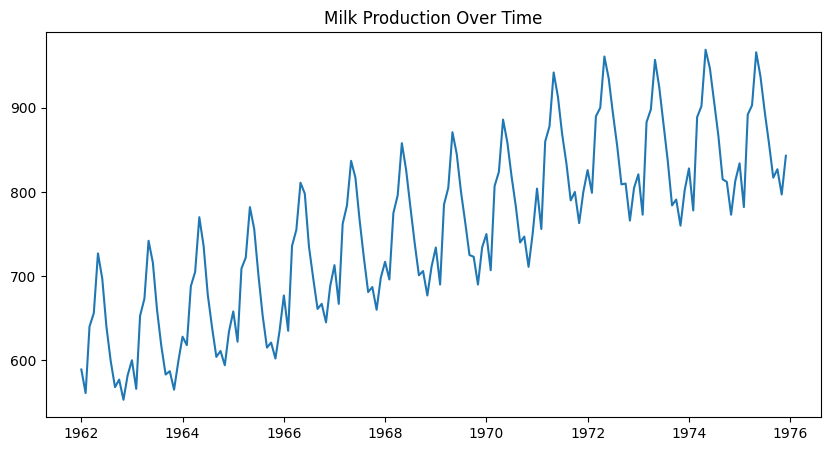

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df)
plt.title('Milk Production Over Time')
plt.show()

Epoch 1/20


C:\Users\SS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1179
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0406 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0233
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200  
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0152
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0141 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0114
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0106 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0099 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0093
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0082 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0073
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10m

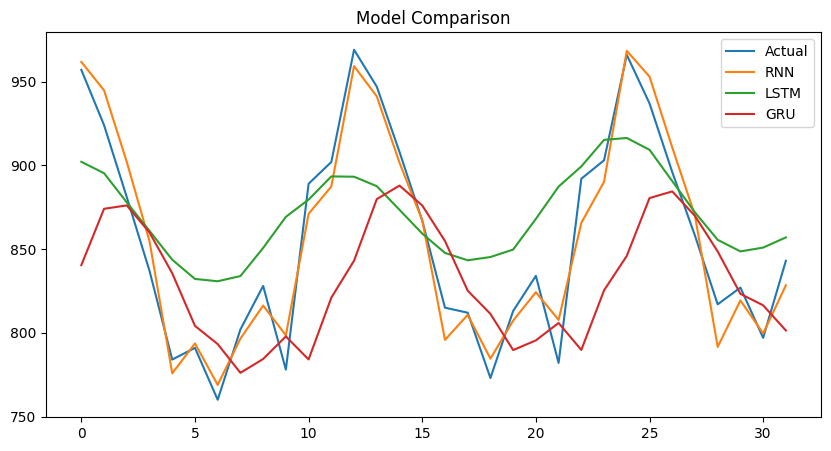

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


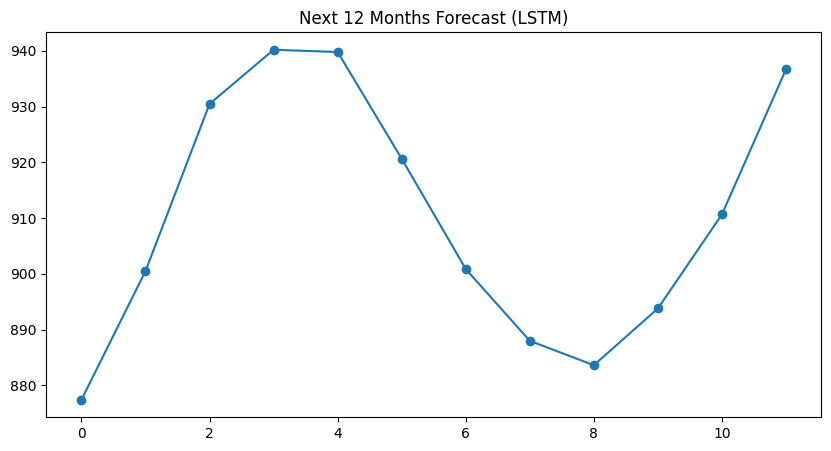


Forecasted Values:
[[877.3946 ]
 [900.4829 ]
 [930.4663 ]
 [940.1855 ]
 [939.78705]
 [920.63776]
 [900.85034]
 [887.97125]
 [883.59564]
 [893.7717 ]
 [910.647  ]
 [936.6814 ]]


In [9]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# =============================
# Create Sequences
# =============================

def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

# Train-test split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =============================
# RNN Model
# =============================

rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

rnn_pred = rnn_model.predict(X_test)

# =============================
# LSTM Model
# =============================

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

lstm_pred = lstm_model.predict(X_test)

# =============================
# GRU Model
# =============================

gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

gru_pred = gru_model.predict(X_test)

# =============================
# Inverse Scaling
# =============================

rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test)

# =============================
# Metrics Function
# =============================

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mae, rmse, mape

print("\nRNN Metrics:", evaluate(y_test_actual, rnn_pred))
print("LSTM Metrics:", evaluate(y_test_actual, lstm_pred))
print("GRU Metrics:", evaluate(y_test_actual, gru_pred))

# =============================
# Plot Predictions
# =============================

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred, label='RNN')
plt.plot(lstm_pred, label='LSTM')
plt.plot(gru_pred, label='GRU')
plt.legend()
plt.title('Model Comparison')
plt.show()

# =============================
# Forecast Next 12 Months
# =============================

last_sequence = scaled_data[-window_size:]
forecast = []

for _ in range(12):
    pred = lstm_model.predict(last_sequence.reshape(1, window_size,1))
    forecast.append(pred[0][0])
    last_sequence = np.append(last_sequence[1:], pred)

forecast = scaler.inverse_transform(np.array(forecast).reshape(-1,1))

plt.figure(figsize=(10,5))
plt.plot(forecast, marker='o')
plt.title('Next 12 Months Forecast (LSTM)')
plt.show()

print("\nForecasted Values:")
print(forecast)
